# 3. Python exploratory analysis

Six figures summarize sample coverage, rated-only ratings, cuisine supply and service associations. Country and city sample sizes should be considered before comparing restaurant performance.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import pandas as pd

from IPython.display import display, Image, Markdown
from src.visualize import make_figures
df = pd.read_csv(ROOT/'data/processed/zomato_cleaned.csv')
bridge = pd.read_csv(ROOT/'data/processed/restaurant_cuisines.csv')
make_figures(df, bridge)

City Coverage


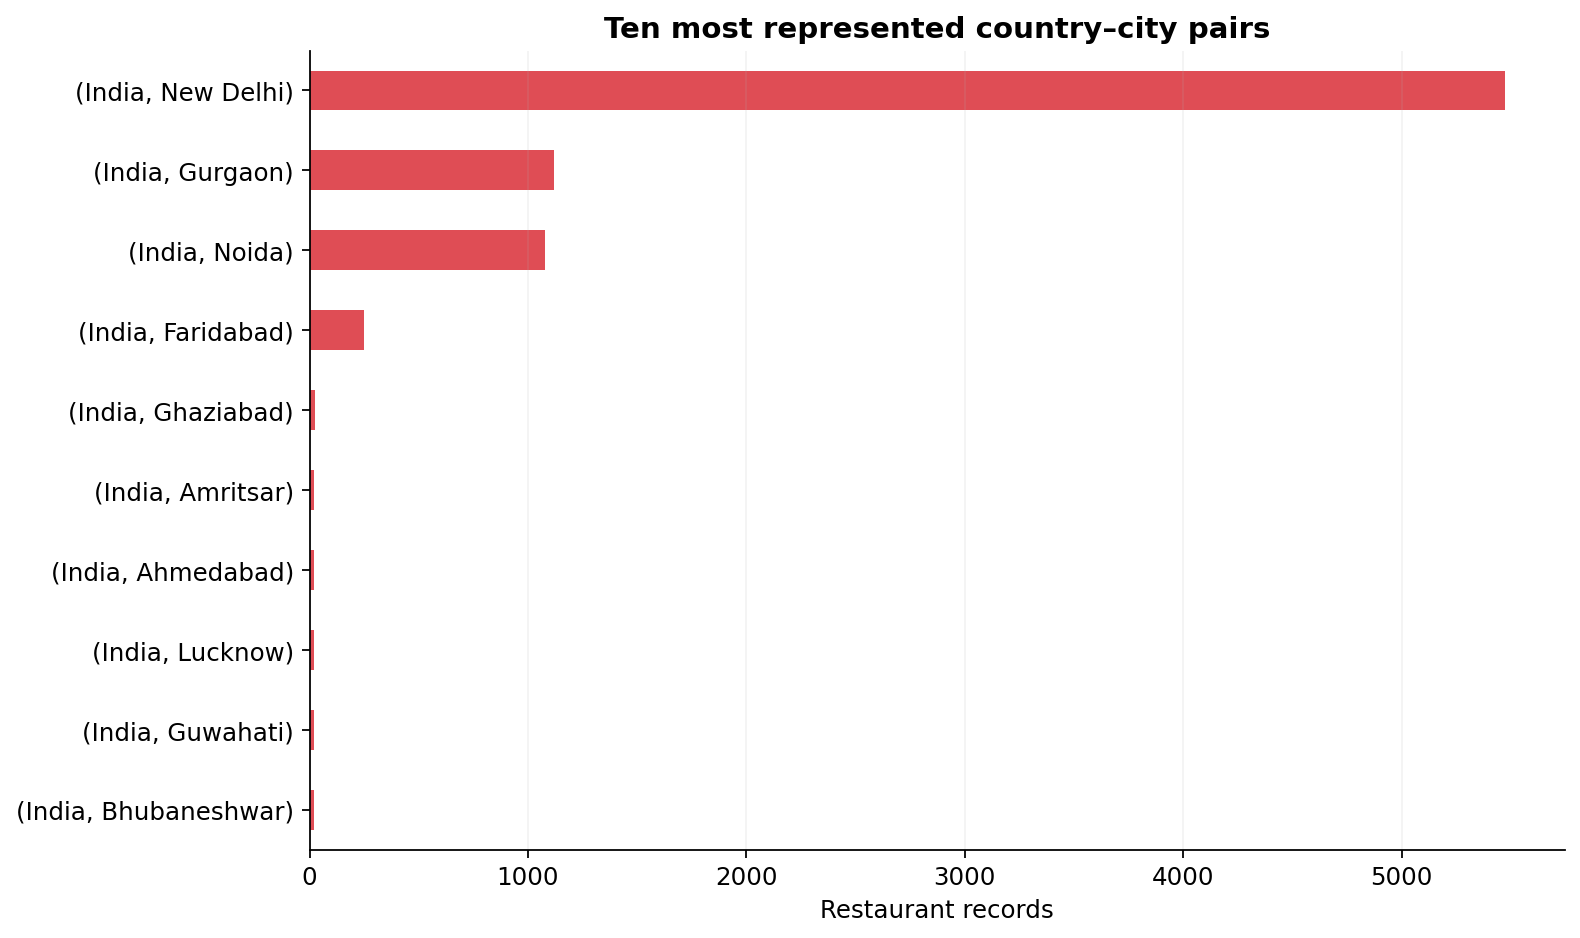

Country Coverage


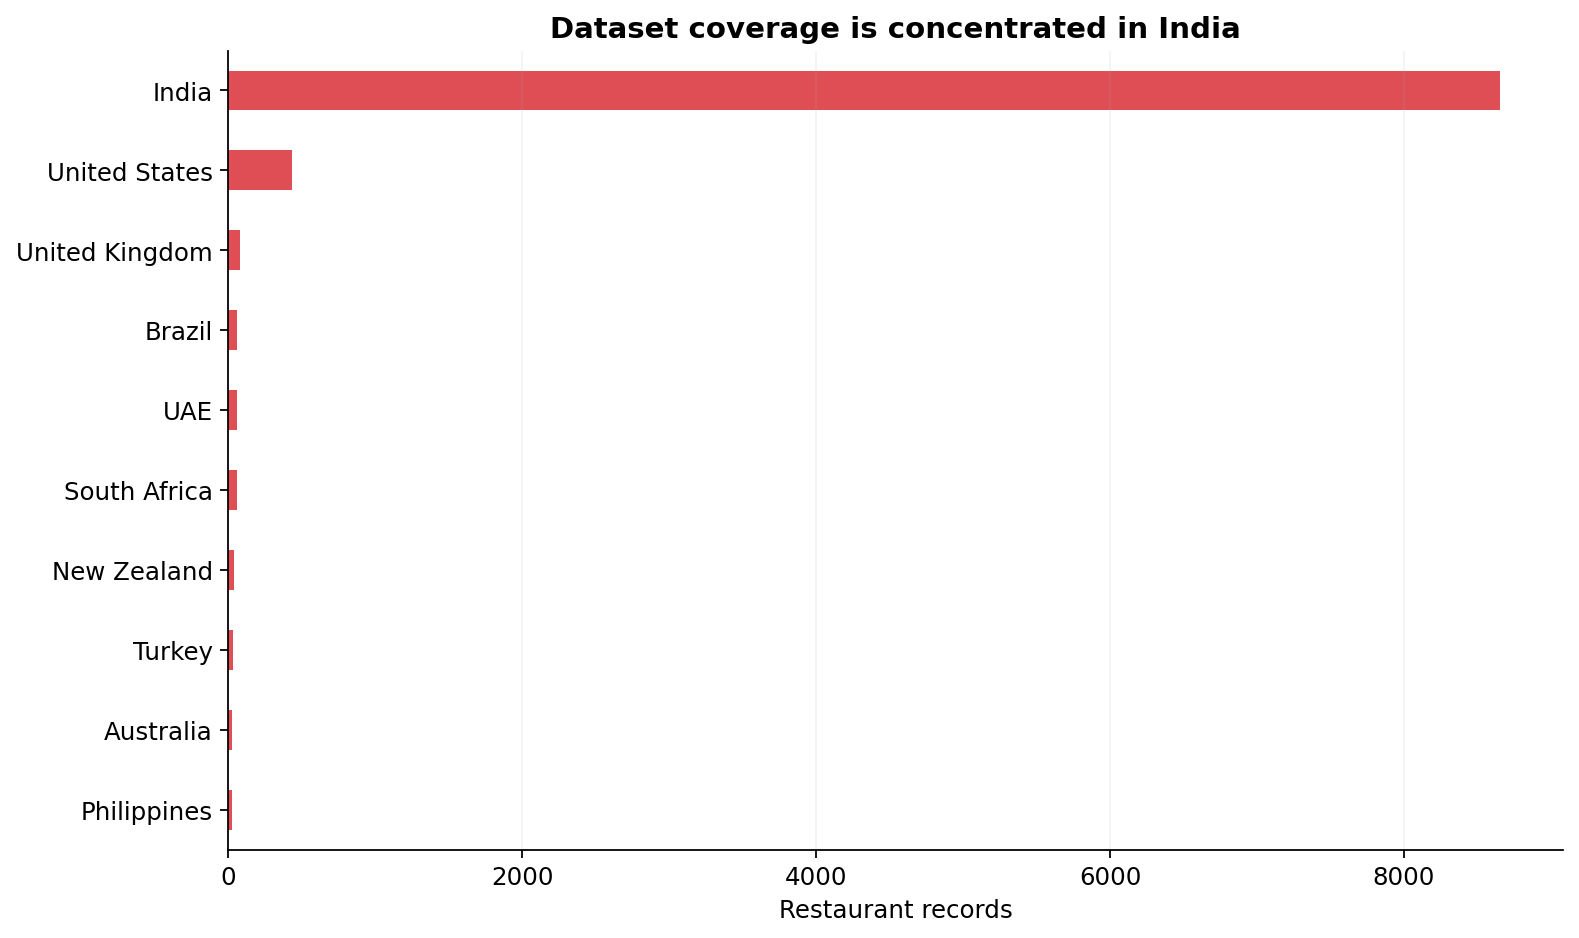

Cuisine Supply


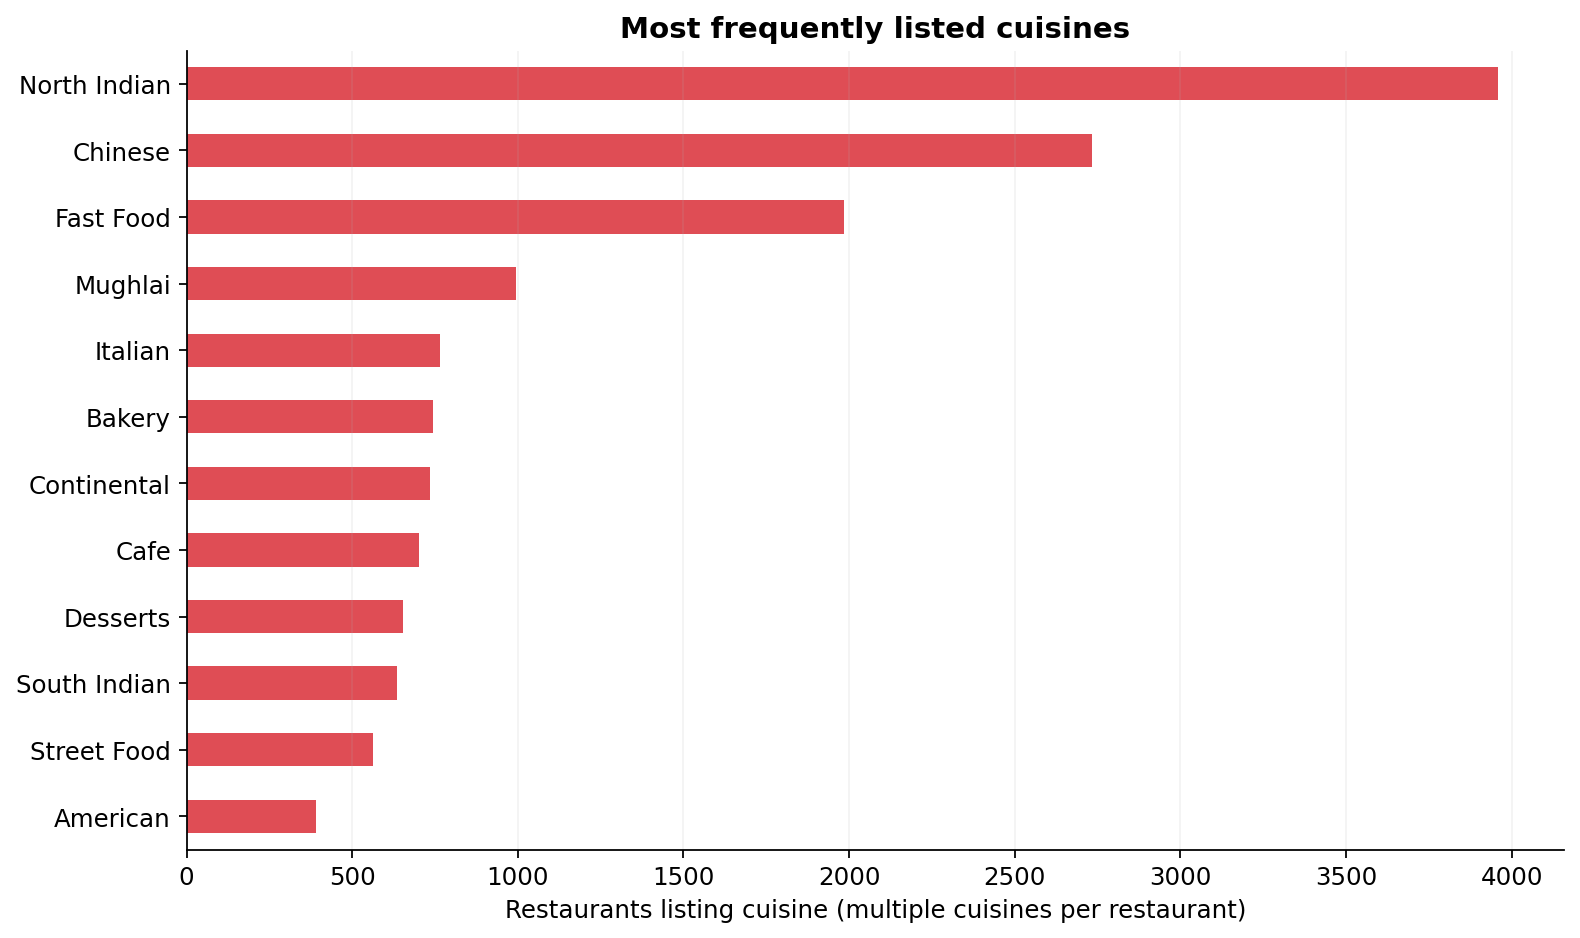

India Price Ratings


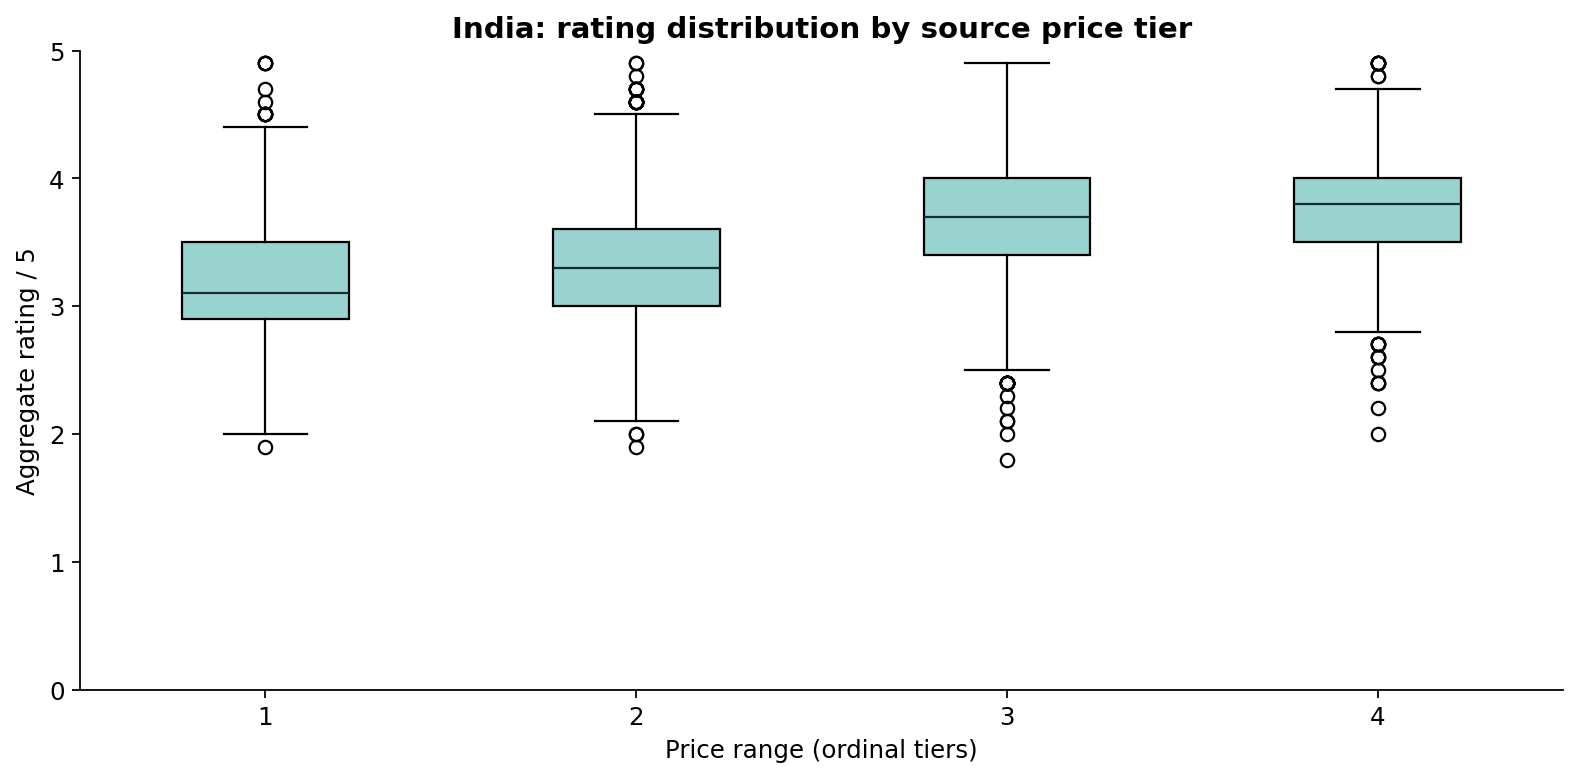

Rating Distribution


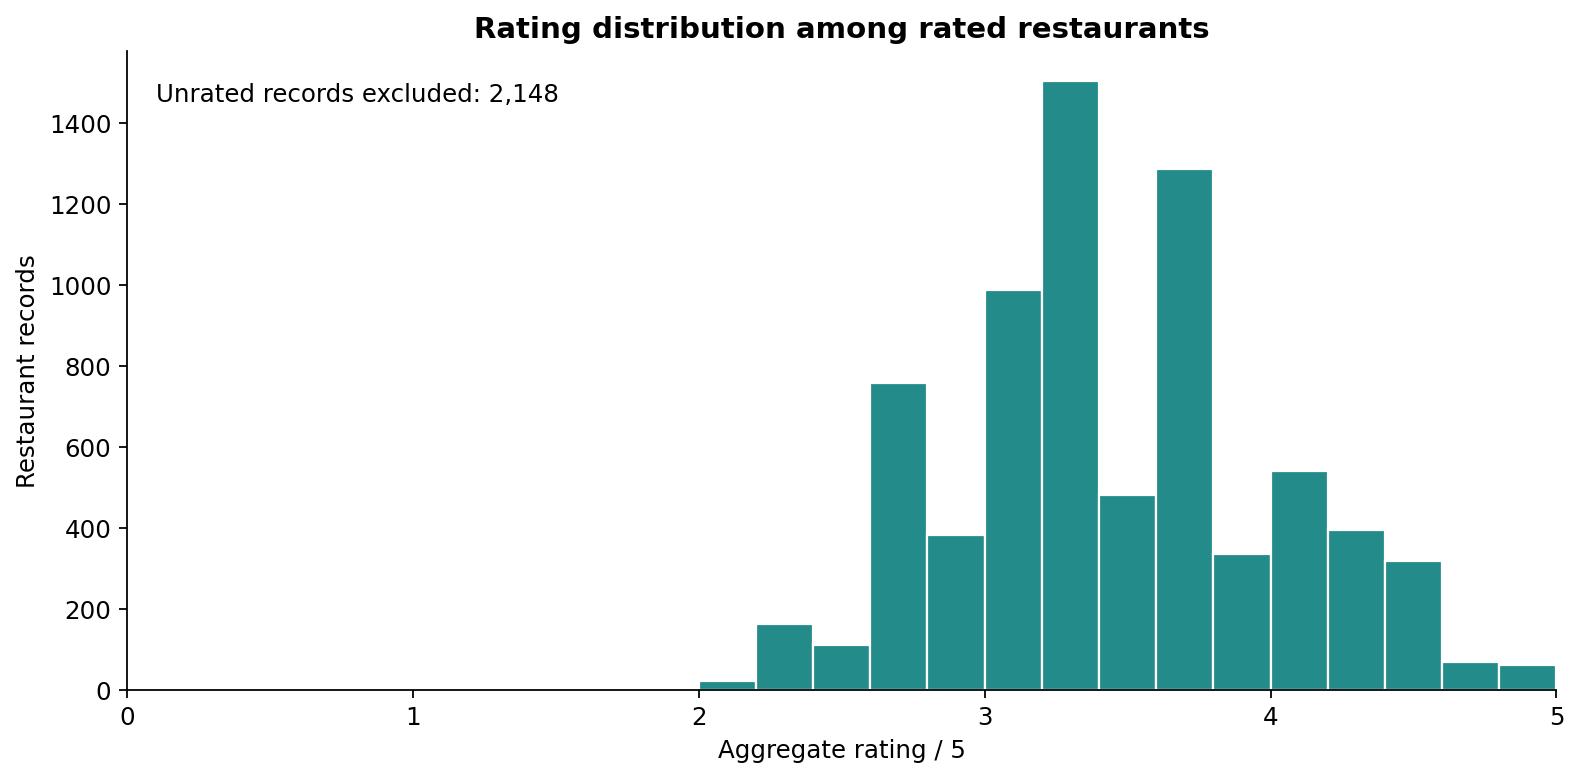

Service Ratings


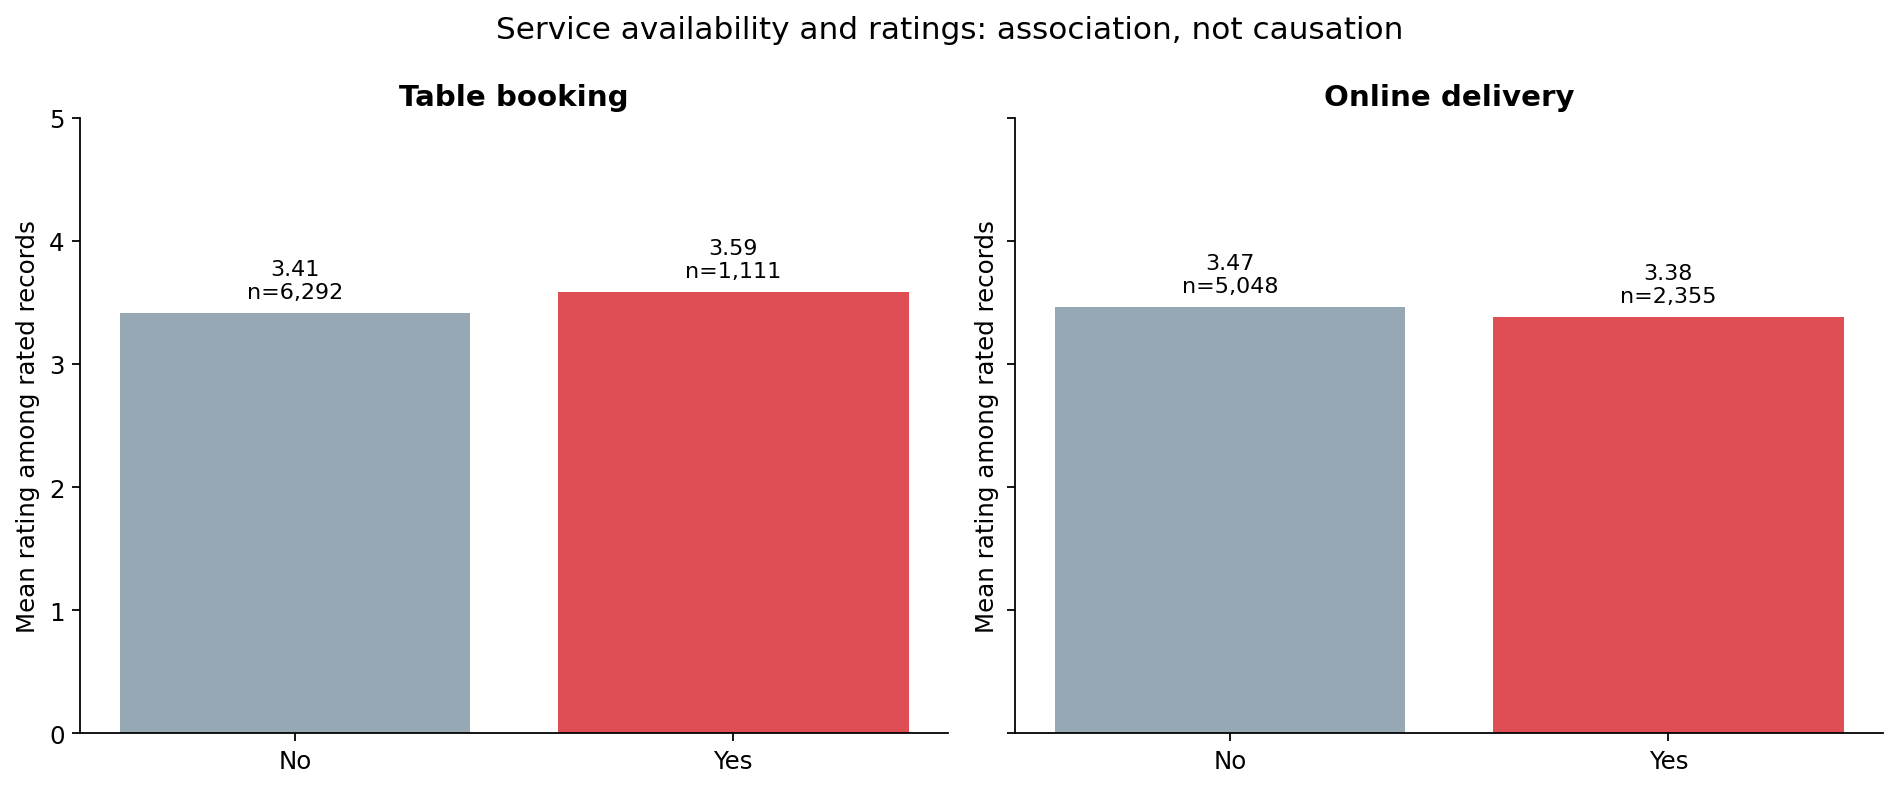

In [2]:
for figure in sorted((ROOT/'reports/figures').glob('*.png')):
    if figure.name == "dashboard.png":
        continue
    print(figure.stem.replace('_',' ').title())
    display(Image(filename=str(figure), width=900))

In [3]:
display(Markdown((ROOT/'reports/findings.md').read_text()))

<!-- Generated by python -m src.pipeline; do not hand-edit metrics. -->
## Computed findings

- **9,551 restaurants** across **15 countries** and **141 country–city pairs**.
- **India accounts for 8,652 restaurants (90.59%)**. This dataset is geographically concentrated.
- **7,403 rated restaurants**; the restaurant-level mean among rated records is **3.44/5**. **2,148 unrated records** are excluded from all mean ratings.
- **1,380 restaurants** have a rating ≥4.0. Of these, **287 (20.80%)** offer table booking.
- **25.66%** of all restaurants offer online delivery; **12.12%** offer table booking.
- **9 missing cuisine records**, **18 zero-cost records**, and **497 zero-coordinate pairs** are flagged rather than invented or silently replaced.

### Interpretation and proposed next steps

Prioritize country and city comparisons over a single global league table because coverage differs sharply. Test booking and delivery hypotheses within the same city and price tier; observed associations cannot establish a service's effect on ratings. Cuisine counts measure listed supply, not customer demand. Validate demand, economics and recent operating status before recommending expansion.

Costs are reported only within country and recorded currency, excluding zero costs. The source has suspicious currency labels (for example Philippine records labelled Botswana Pula); no exchange-rate conversion or undocumented correction is applied. Price range is an ordinal source category, not a common monetary scale.


## Decision implications

Use these patterns to form hypotheses for a current, local study. Assess table booking and delivery within the same location and price tier. Cuisine supply alone cannot identify unmet demand. Gather customer demand, operating costs and recent restaurant data before investment decisions.